# Figure 6: Empirical counterfactual outcome distributions

This notebook reproduces **Figure 6** in the paper.

For each empirical dataset, it uses the distributional inference routine in `mmscm.py` to generate samples from the estimated counterfactual distribution and then plots the corresponding density estimates.

## How to run

Run all cells from top to bottom.

## Notes

- The notebook reads the empirical datasets from `dataset/`.
- A fixed NumPy random seed is used because the distributional inference routine samples from the estimated counterfactual distribution.
- The final plots correspond to the three panels of Figure 6.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mmscm import *

from scipy.stats import gaussian_kde

DATA_DIR = "dataset/"

In [3]:
np.random.seed(0)  # reproducibility for dist_infernece() sampling

In [9]:
#Import data
data = pd.read_csv(DATA_DIR + "german_reunification.csv")
data = data.drop(columns="code", axis=1)

In [10]:
target_var = "country"
target_unit = "West Germany"
target_year_var = "year"
target_year = 1990

target_val = "gdp"

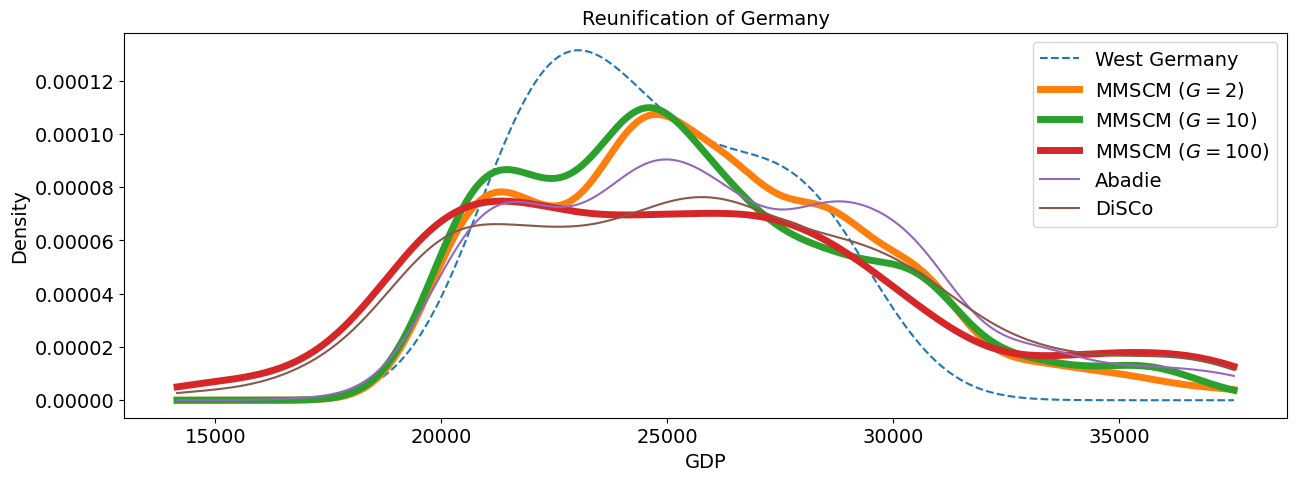

In [11]:
abadiescm = MMSCM(data, "Abadie", target_var, target_unit, target_val, target_year_var, target_year)
abadiescm.train_param()
orignal_val, abadiescm_pred = abadiescm.dist_infernece()

mmscm2 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=2)
mmscm2.train_param()
orignal_val, mmscm_pred2 = mmscm2.dist_infernece()

mmscm10 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=10)
mmscm10.train_param()
orignal_val, mmscm_pred10 = mmscm10.dist_infernece()

mmscm100 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=100)
mmscm100.train_param()
orignal_val, mmscm_pred100 = mmscm100.dist_infernece()

disco = MMSCM(data, "DiSCo", target_var, target_unit, target_val, target_year_var, target_year, poly=100)
disco.train_param()
orignal_val, disco_pred = disco.dist_infernece()

all_data = list(orignal_val) + abadiescm_pred + mmscm_pred2 + mmscm_pred10 + mmscm_pred100 + disco_pred
x_grid = np.linspace(min(all_data), max(all_data), num=1000)

kde = gaussian_kde(orignal_val)
y_actual = kde(x_grid)

kde = gaussian_kde(abadiescm_pred)
y_counterfactual_abadie = kde(x_grid)

kde = gaussian_kde(mmscm_pred2)
y_counterfactual_g2 = kde(x_grid)

kde = gaussian_kde(mmscm_pred10)
y_counterfactual_g10 = kde(x_grid)

kde = gaussian_kde(mmscm_pred100)
y_counterfactual_g100 = kde(x_grid)

kde = gaussian_kde(disco_pred)
y_counterfactual_disco = kde(x_grid)

plt.figure(figsize=(15,5))
plt.plot(x_grid, y_actual, label="West Germany", linestyle="dashed")
plt.plot(x_grid, y_counterfactual_g2, label="MMSCM ($G = 2$)", linewidth=5)
plt.plot(x_grid, y_counterfactual_g10, label="MMSCM ($G = 10$)", linewidth=5)
plt.plot(x_grid, y_counterfactual_g100, label="MMSCM ($G = 100$)", linewidth=5)
plt.plot(x_grid, y_counterfactual_abadie, label="Abadie")
plt.plot(x_grid, y_counterfactual_disco, label="DiSCo")

plt.title("Reunification of Germany", size = 14)
plt.xlabel("GDP", size = 14, weight = "light")
plt.ylabel("Density", size = 14, weight = "light")

plt.xticks(size = 14)
plt.yticks(size = 14)

plt.legend(fontsize = 14)
plt.show()


In [12]:
#Import data
data = pd.read_csv(DATA_DIR + "basque_data" + ".csv")
data = data.drop(columns=["regionno", "Unnamed: 0"], axis=1) #Drop superfluous columns
data = data.loc[data["regionname"] != "Spain (Espana)"] #Exclude spain as a valid control unit, as it includes basque, the treated unit.

In [13]:
target_var = "regionname"
target_unit = "Basque Country (Pais Vasco)"
target_year_var = "year"
target_year = 1970

target_val = "gdpcap"

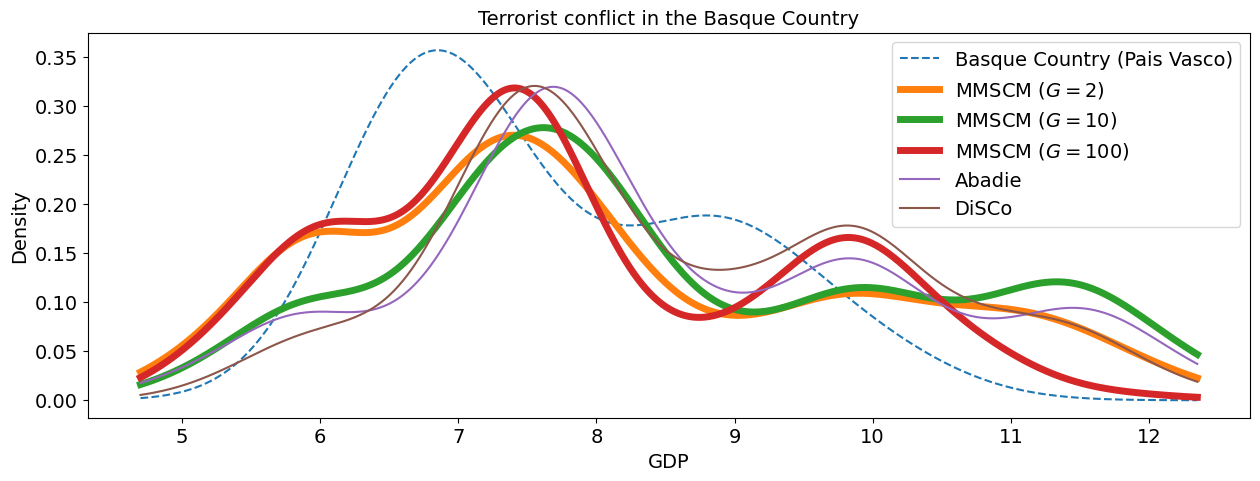

In [14]:
abadiescm = MMSCM(data, "Abadie", target_var, target_unit, target_val, target_year_var, target_year)
abadiescm.train_param()
orignal_val, abadiescm_pred = abadiescm.dist_infernece()

mmscm2 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=2)
mmscm2.train_param()
orignal_val, mmscm_pred2 = mmscm2.dist_infernece()

mmscm10 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=10)
mmscm10.train_param()
orignal_val, mmscm_pred10 = mmscm10.dist_infernece()

mmscm100 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=100)
mmscm100.train_param()
orignal_val, mmscm_pred100 = mmscm100.dist_infernece()

disco = MMSCM(data, "DiSCo", target_var, target_unit, target_val, target_year_var, target_year, poly=100)
disco.train_param()
orignal_val, disco_pred = disco.dist_infernece()

all_data = list(orignal_val) + abadiescm_pred + mmscm_pred2 + mmscm_pred10 + mmscm_pred100 + disco_pred
x_grid = np.linspace(min(all_data), max(all_data), num=1000)

kde = gaussian_kde(orignal_val)
y_actual = kde(x_grid)

kde = gaussian_kde(abadiescm_pred)
y_counterfactual_abadie = kde(x_grid)

kde = gaussian_kde(mmscm_pred2)
y_counterfactual_g2 = kde(x_grid)

kde = gaussian_kde(mmscm_pred10)
y_counterfactual_g10 = kde(x_grid)

kde = gaussian_kde(mmscm_pred100)
y_counterfactual_g100 = kde(x_grid)

kde = gaussian_kde(disco_pred)
y_counterfactual_disco = kde(x_grid)

plt.figure(figsize=(15,5))
plt.plot(x_grid, y_actual, label="Basque Country (Pais Vasco)", linestyle="dashed")
plt.plot(x_grid, y_counterfactual_g2, label="MMSCM ($G = 2$)", linewidth=5)
plt.plot(x_grid, y_counterfactual_g10, label="MMSCM ($G = 10$)", linewidth=5)
plt.plot(x_grid, y_counterfactual_g100, label="MMSCM ($G = 100$)", linewidth=5)
plt.plot(x_grid, y_counterfactual_abadie, label="Abadie")
plt.plot(x_grid, y_counterfactual_disco, label="DiSCo")

plt.title("Terrorist conflict in the Basque Country", size = 14)
plt.xlabel("GDP", size = 14, weight = "light")
plt.ylabel("Density", size = 14, weight = "light")

plt.xticks(size = 14)
plt.yticks(size = 14)

plt.legend(fontsize = 14)
plt.show()


In [15]:
#Import data
data = pd.read_csv(DATA_DIR + "smoking_data.csv")

In [16]:
target_var = "state"
target_unit = "California"
target_year_var = "year"
target_year = 1989

target_val = "cigsale"

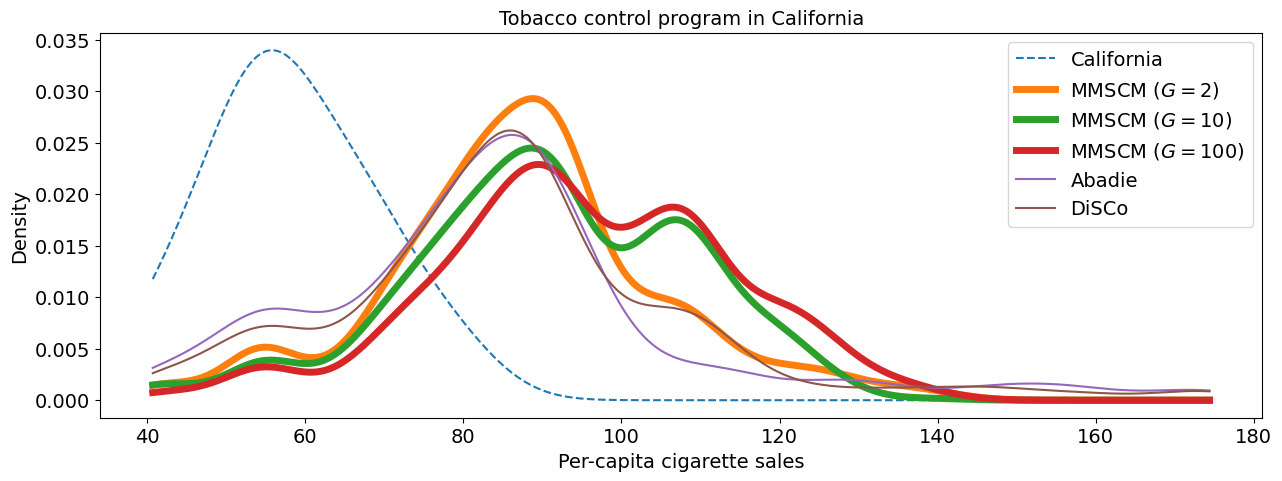

In [17]:
abadiescm = MMSCM(data, "Abadie", target_var, target_unit, target_val, target_year_var, target_year)
abadiescm.train_param()
orignal_val, abadiescm_pred = abadiescm.dist_infernece()

mmscm2 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=2)
mmscm2.train_param()
orignal_val, mmscm_pred2 = mmscm2.dist_infernece()

mmscm10 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=10)
mmscm10.train_param()
orignal_val, mmscm_pred10 = mmscm10.dist_infernece()

mmscm100 = MMSCM(data, "MMSCM", target_var, target_unit, target_val, target_year_var, target_year, poly=100)
mmscm100.train_param()
orignal_val, mmscm_pred100 = mmscm100.dist_infernece()

disco = MMSCM(data, "DiSCo", target_var, target_unit, target_val, target_year_var, target_year, poly=100)
disco.train_param()
orignal_val, disco_pred = disco.dist_infernece()

all_data = list(orignal_val) + abadiescm_pred + mmscm_pred2 + mmscm_pred10 + mmscm_pred100 + disco_pred
x_grid = np.linspace(min(all_data), max(all_data), num=1000)

kde = gaussian_kde(orignal_val)
y_actual = kde(x_grid)

kde = gaussian_kde(abadiescm_pred)
y_counterfactual_abadie = kde(x_grid)

kde = gaussian_kde(mmscm_pred2)
y_counterfactual_g2 = kde(x_grid)

kde = gaussian_kde(mmscm_pred10)
y_counterfactual_g10 = kde(x_grid)

kde = gaussian_kde(mmscm_pred100)
y_counterfactual_g100 = kde(x_grid)

kde = gaussian_kde(disco_pred)
y_counterfactual_disco = kde(x_grid)

plt.figure(figsize=(15,5))
plt.plot(x_grid, y_actual, label="California", linestyle="dashed")
plt.plot(x_grid, y_counterfactual_g2, label="MMSCM ($G = 2$)", linewidth=5)
plt.plot(x_grid, y_counterfactual_g10, label="MMSCM ($G = 10$)", linewidth=5)
plt.plot(x_grid, y_counterfactual_g100, label="MMSCM ($G = 100$)", linewidth=5)
plt.plot(x_grid, y_counterfactual_abadie, label="Abadie")
plt.plot(x_grid, y_counterfactual_disco, label="DiSCo")

plt.title("Tobacco control program in California", size = 14)
plt.ylabel("Density", size = 14, weight = "light")
plt.xlabel("Per-capita cigarette sales", size = 14, weight = "light")

plt.xticks(size = 14)
plt.yticks(size = 14)

plt.legend(fontsize = 14)
plt.show()
